# Accounts Receivable (AR) & Payment Collection Analysis

## Exploratory Data Analysis (EDA)

### Objective

The objective of this notebook is to explore the cleaned Accounts Receivable datasets and generate business insights related to customer payments, outstanding invoices, collections, credit exposure, and cash flow.

The analysis focuses on answering key finance and FP&A business questions that help improve collection efficiency, reduce overdue receivables, and monitor customer credit risk.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [2]:
customers = pd.read_csv("customers_clean.csv")
invoices = pd.read_csv("invoices_clean.csv")
payments = pd.read_csv("payments_clean.csv")
sales = pd.read_csv("sales_clean.csv")
credit = pd.read_csv("credit_clean.csv")

In [3]:
invoices["Invoice_Date"] = pd.to_datetime(invoices["Invoice_Date"])
invoices["Due_Date"] = pd.to_datetime(invoices["Due_Date"])

payments["Payment_Date"] = pd.to_datetime(payments["Payment_Date"])

sales["Sales_Date"] = pd.to_datetime(sales["Sales_Date"])

In [4]:
today = pd.Timestamp.today().normalize()

# Days since invoice was created
invoices["Invoice_Age"] = (
    today - invoices["Invoice_Date"]
).dt.days

# Days overdue (positive means overdue)
invoices["Days_Overdue"] = (
    today - invoices["Due_Date"]
).dt.days

In [5]:
def aging_bucket(days):
    if days <= 30:
        return "0-30 Days"
    elif days <= 60:
        return "31-60 Days"
    elif days <= 90:
        return "61-90 Days"
    else:
        return "90+ Days"

invoices["Aging_Bucket"] = invoices["Days_Overdue"].apply(aging_bucket)

In [6]:
ar = (
    invoices
    .merge(customers, on="Customer_ID", how="left")
    .merge(credit, on="Customer_ID", how="left", suffixes=("", "_Credit"))
)

In [7]:
ar.head()

,Invoice_ID,Customer_ID,Invoice_Date,Due_Date,Invoice_Amount,Status,Invoice_Age,Days_Overdue,Aging_Bucket,Customer_Name,Region,Industry,Credit_Limit,Payment_Terms,Account_Manager,Credit_Limit_Credit,Current_Exposure,Risk_Rating,Utilization
0,INV00001,C0383,2025-05-02,2025-07-03,42847.0,Paid,442,380,90+ Days,Customer 383,West,IT,252713,Net 30,Manager 3,252713,294744,Medium,116.63%
1,INV00002,C0198,2024-04-25,2024-10-05,33240.0,Paid,814,651,90+ Days,Customer 198,South,Wholesale,239676,Net 60,Manager 8,239676,107380,High,44.80%
2,INV00003,C0185,2024-11-20,2024-05-12,25851.0,Outstanding,605,797,90+ Days,Customer 185,West,Retail,295732,Net 60,Manager 5,295732,83374,High,28.19%
3,INV00004,C0292,2025-06-03,2025-05-04,36306.0,Paid,410,440,90+ Days,Customer 292,North,Manufacturing,193272,Net 60,Manager 5,193272,205783,High,106.47%
4,INV00005,C0009,2025-08-24,2025-08-09,1403.0,Paid,328,343,90+ Days,Customer 9,North,IT,100707,Net 30,Manager 6,100707,107754,Low,107.00%


In [8]:
print(ar.shape)

ar.head()

(7994, 19)


,Invoice_ID,Customer_ID,Invoice_Date,Due_Date,Invoice_Amount,Status,Invoice_Age,Days_Overdue,Aging_Bucket,Customer_Name,Region,Industry,Credit_Limit,Payment_Terms,Account_Manager,Credit_Limit_Credit,Current_Exposure,Risk_Rating,Utilization
0,INV00001,C0383,2025-05-02,2025-07-03,42847.0,Paid,442,380,90+ Days,Customer 383,West,IT,252713,Net 30,Manager 3,252713,294744,Medium,116.63%
1,INV00002,C0198,2024-04-25,2024-10-05,33240.0,Paid,814,651,90+ Days,Customer 198,South,Wholesale,239676,Net 60,Manager 8,239676,107380,High,44.80%
2,INV00003,C0185,2024-11-20,2024-05-12,25851.0,Outstanding,605,797,90+ Days,Customer 185,West,Retail,295732,Net 60,Manager 5,295732,83374,High,28.19%
3,INV00004,C0292,2025-06-03,2025-05-04,36306.0,Paid,410,440,90+ Days,Customer 292,North,Manufacturing,193272,Net 60,Manager 5,193272,205783,High,106.47%
4,INV00005,C0009,2025-08-24,2025-08-09,1403.0,Paid,328,343,90+ Days,Customer 9,North,IT,100707,Net 30,Manager 6,100707,107754,Low,107.00%


In [9]:
ar.describe(include="all")

,Invoice_ID,Customer_ID,Invoice_Date,Due_Date,Invoice_Amount,Status,Invoice_Age,Days_Overdue,Aging_Bucket,Customer_Name,Region,Industry,Credit_Limit,Payment_Terms,Account_Manager,Credit_Limit_Credit,Current_Exposure,Risk_Rating,Utilization
count,7994,7994,7994,7994,7994.000000,7994,7994.000000,7994.000000,7994,7994,7994,7994,7994.000000,7994,7994,7994.000000,7994.000000,7994,7994
unique,7994,500,NaN,NaN,NaN,3,NaN,NaN,4,500,4,5,NaN,3,15,NaN,NaN,3,487
top,INV00001,C0243,NaN,NaN,NaN,Paid,NaN,NaN,90+ Days,Customer 243,West,Wholesale,NaN,Net 30,Manager 6,NaN,NaN,Medium,94.45%
freq,1,30,NaN,NaN,NaN,5928,NaN,NaN,7840,30,2231,1891,NaN,2826,914,NaN,NaN,2799,49
mean,NaN,NaN,2025-01-04 12:15:18.689016,2025-02-09 16:37:35.291468,25310.041906,NaN,559.489367,523.307230,NaN,NaN,NaN,NaN,282424.318614,NaN,NaN,282424.318614,176190.241681,NaN,NaN
min,NaN,NaN,2024-01-01 00:00:00,2024-01-02 00:00:00,503.000000,NaN,199.000000,-137.000000,NaN,NaN,NaN,NaN,50820.000000,NaN,NaN,50820.000000,11296.000000,NaN,NaN
25%,NaN,NaN,2024-07-05 00:00:00,2024-08-04 00:00:00,12971.000000,NaN,377.000000,339.000000,NaN,NaN,NaN,NaN,165040.000000,NaN,NaN,165040.000000,64522.000000,NaN,NaN
50%,NaN,NaN,2025-01-08 00:00:00,2025-02-12 00:00:00,25572.500000,NaN,556.000000,521.000000,NaN,NaN,NaN,NaN,285196.000000,NaN,NaN,285196.000000,147790.000000,NaN,NaN
75%,NaN,NaN,2025-07-06 00:00:00,2025-08-13 00:00:00,37631.750000,NaN,743.000000,713.000000,NaN,NaN,NaN,NaN,396512.000000,NaN,NaN,396512.000000,267213.000000,NaN,NaN
max,NaN,NaN,2025-12-31 00:00:00,2026-12-02 00:00:00,49981.000000,NaN,929.000000,928.000000,NaN,NaN,NaN,NaN,499699.000000,NaN,NaN,499699.000000,591141.000000,NaN,NaN


In [10]:
(ar["Credit_Limit"] == ar["Credit_Limit_Credit"]).all()

np.True_

In [11]:
ar.drop(columns=["Credit_Limit_Credit"], inplace=True)

In [12]:
ar.columns

Index(['Invoice_ID', 'Customer_ID', 'Invoice_Date', 'Due_Date',
       'Invoice_Amount', 'Status', 'Invoice_Age', 'Days_Overdue',
       'Aging_Bucket', 'Customer_Name', 'Region', 'Industry', 'Credit_Limit',
       'Payment_Terms', 'Account_Manager', 'Current_Exposure', 'Risk_Rating',
       'Utilization'],
      dtype='str')

In [13]:
ar = ar[
    [
        "Invoice_ID",
        "Customer_ID",
        "Customer_Name",
        "Region",
        "Industry",
        "Invoice_Date",
        "Due_Date",
        "Invoice_Amount",
        "Status",
        "Invoice_Age",
        "Days_Overdue",
        "Aging_Bucket",
        "Credit_Limit",
        "Current_Exposure",
        "Risk_Rating",
        "Utilization",
        "Payment_Terms",
        "Account_Manager",
    ]
]

# Analysis 1: Monthly Cash Collections

### Business Question

How much cash did the company collect each month?


In [15]:
monthly_collection = (
    payments
    .groupby(payments["Payment_Date"].dt.to_period("M"))["Amount_Paid"]
    .sum()
    .reset_index()
)

monthly_collection["Payment_Date"] = monthly_collection["Payment_Date"].astype(str)

monthly_collection

,Payment_Date,Amount_Paid
0,2024-01,2852356
1,2024-02,3673702
2,2024-03,6338587
3,2024-04,6030406
4,2024-05,6845234
5,2024-06,7110653
6,2024-07,5569183
7,2024-08,6202283
8,2024-09,5378531
9,2024-10,6641203


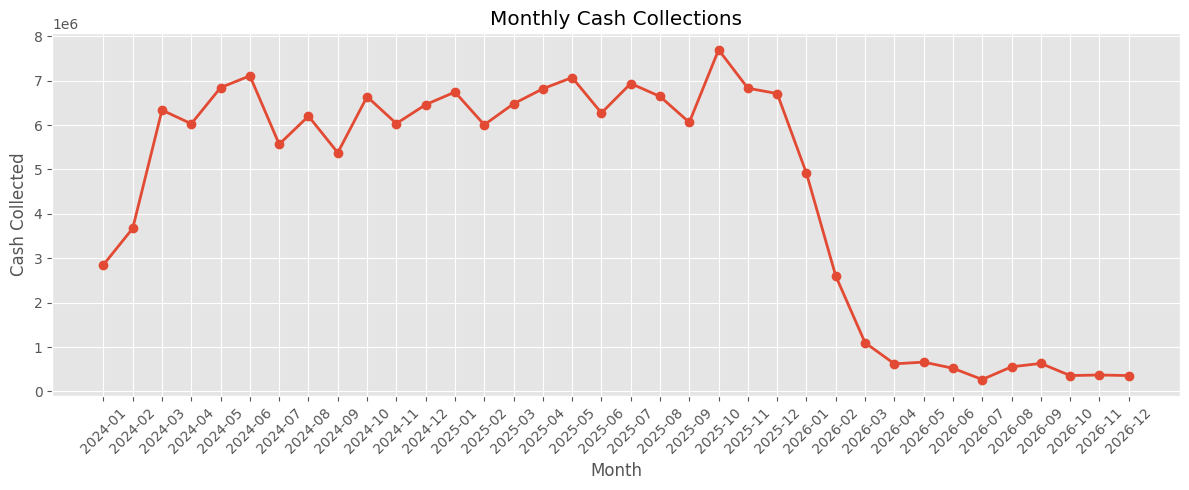

In [16]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_collection["Payment_Date"],
    monthly_collection["Amount_Paid"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Cash Collections")
plt.xlabel("Month")
plt.ylabel("Cash Collected")

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.show()

# Analysis 2: Payment Status Distribution

### Business Question

What is the distribution of invoice payment statuses?

Understanding the proportion of paid, partially paid, and outstanding invoices helps evaluate the overall effectiveness of the accounts receivable collection process.

In [17]:
status = invoices["Status"].value_counts()

status

Status
Paid              5928
Outstanding       1249
Partially Paid     817
Name: count, dtype: int64

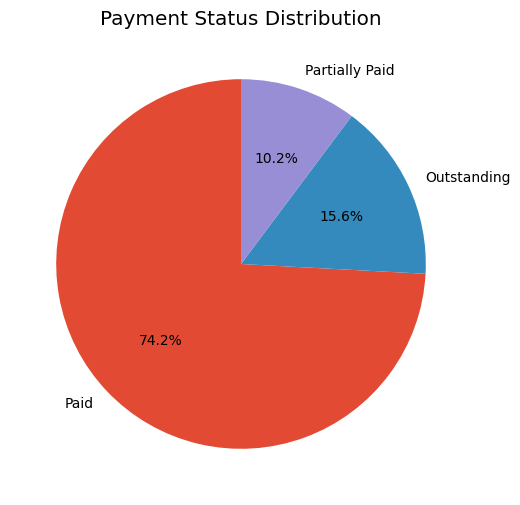

In [18]:
plt.figure(figsize=(6,6))

plt.pie(
    status,
    labels=status.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Payment Status Distribution")

plt.show()

# Analysis 3: Outstanding Invoice Amount

### Business Question

How much value is currently tied up in outstanding invoices?

Outstanding invoices represent cash that has not yet been collected and directly impact the company's liquidity.

In [19]:
outstanding = invoices[
    invoices["Status"] != "Paid"
]["Invoice_Amount"].sum()

print(f"Total Outstanding Amount: ₹{outstanding:,.0f}")

Total Outstanding Amount: ₹52,242,083


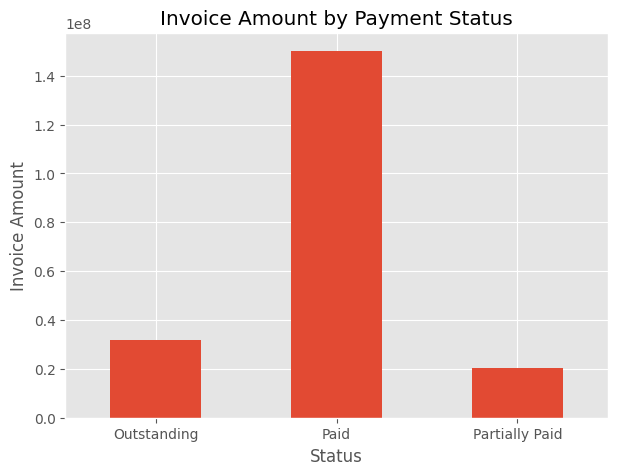

In [20]:
status_amount = (
    invoices.groupby("Status")["Invoice_Amount"]
    .sum()
)

plt.figure(figsize=(7,5))

status_amount.plot(kind="bar")

plt.title("Invoice Amount by Payment Status")
plt.xlabel("Status")
plt.ylabel("Invoice Amount")

plt.xticks(rotation=0)

plt.show()

# Analysis 4: Invoice Aging Analysis

## Business Question

How are outstanding invoices distributed across aging categories?

Invoice aging helps the finance team identify overdue receivables, prioritize collection efforts, and evaluate the risk of delayed customer payments. Older invoices generally represent a higher collection risk and may require immediate follow-up.

In [21]:
aging_summary = (
    ar.groupby("Aging_Bucket")["Invoice_Amount"]
    .sum()
    .reset_index()
)

aging_summary

,Aging_Bucket,Invoice_Amount
0,0-30 Days,2805614.0
1,31-60 Days,628611.0
2,61-90 Days,598374.0
3,90+ Days,198295876.0


In [22]:
order = [
    "0-30 Days",
    "31-60 Days",
    "61-90 Days",
    "90+ Days"
]

aging_summary["Aging_Bucket"] = pd.Categorical(
    aging_summary["Aging_Bucket"],
    categories=order,
    ordered=True
)

aging_summary = aging_summary.sort_values("Aging_Bucket")

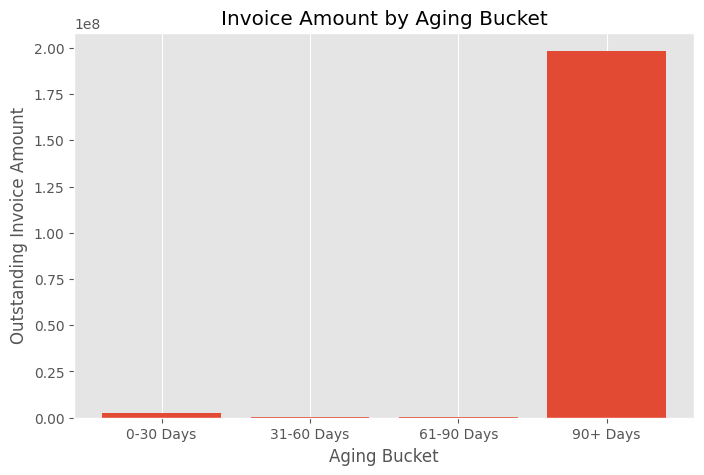

In [23]:
plt.figure(figsize=(8,5))

plt.bar(
    aging_summary["Aging_Bucket"],
    aging_summary["Invoice_Amount"]
)

plt.title("Invoice Amount by Aging Bucket")

plt.xlabel("Aging Bucket")

plt.ylabel("Outstanding Invoice Amount")

plt.grid(axis="y")

plt.show()

In [24]:
aging_summary

,Aging_Bucket,Invoice_Amount
0,0-30 Days,2805614.0
1,31-60 Days,628611.0
2,61-90 Days,598374.0
3,90+ Days,198295876.0


# Analysis 5: Top 10 Overdue Customers

## Business Question

Which customers have the highest overdue invoice amounts?

Identifying customers with the largest overdue balances helps the finance team prioritize collection efforts and reduce outstanding receivables.

In [25]:
top_overdue = (
    ar[ar["Status"] != "Paid"]
    .groupby("Customer_Name")["Invoice_Amount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_overdue

Customer_Name
Customer 489    386232.0
Customer 471    362087.0
Customer 96     328280.0
Customer 358    296951.0
Customer 287    266570.0
Customer 48     260156.0
Customer 468    255973.0
Customer 263    251749.0
Customer 23     247660.0
Customer 152    247443.0
Name: Invoice_Amount, dtype: float64

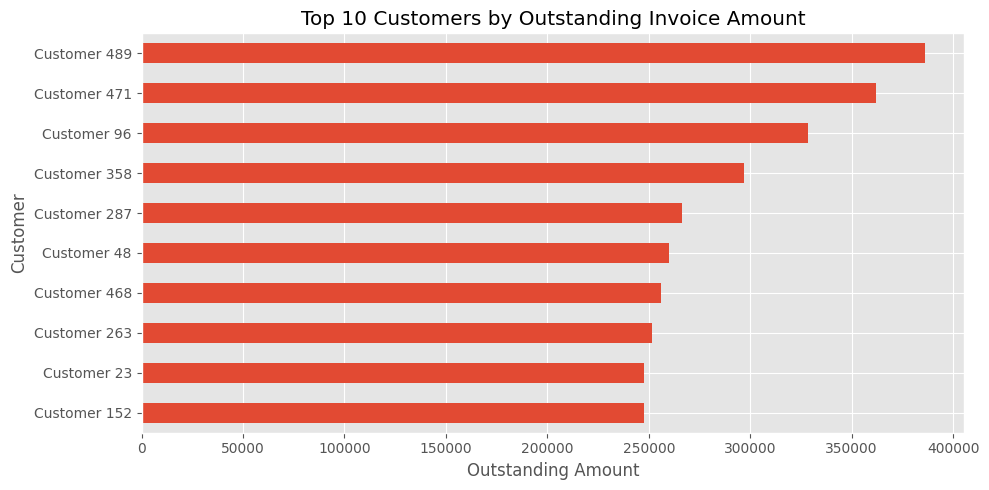

In [26]:
plt.figure(figsize=(10,5))

top_overdue.sort_values().plot(kind="barh")

plt.title("Top 10 Customers by Outstanding Invoice Amount")
plt.xlabel("Outstanding Amount")
plt.ylabel("Customer")

plt.tight_layout()
plt.show()

# Analysis 6: Region-wise Outstanding Receivables

## Business Question

Which regions contribute the most to outstanding receivables?

Regional analysis helps identify geographical areas where collection performance may require additional attention.

In [27]:
region_receivable = (
    ar[ar["Status"] != "Paid"]
    .groupby("Region")["Invoice_Amount"]
    .sum()
    .sort_values(ascending=False)
)

region_receivable

Region
West     14546456.0
South    13748878.0
East     12183746.0
North    11763003.0
Name: Invoice_Amount, dtype: float64

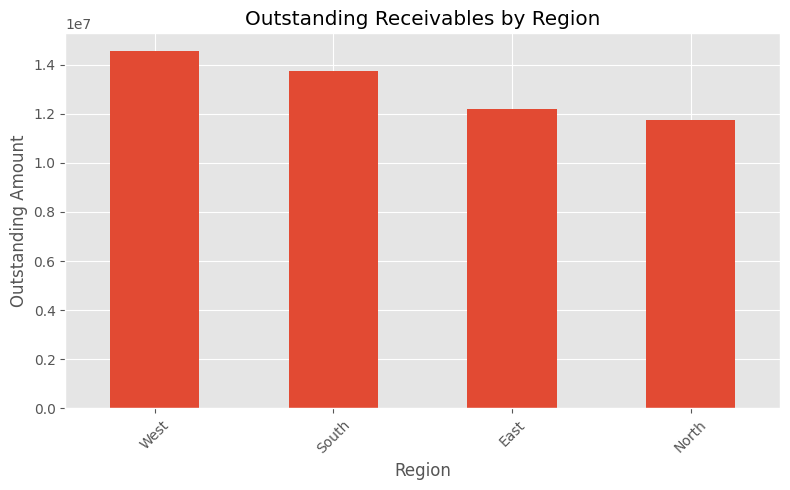

In [28]:
plt.figure(figsize=(8,5))

region_receivable.plot(kind="bar")

plt.title("Outstanding Receivables by Region")
plt.ylabel("Outstanding Amount")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Analysis 7: Industry-wise Outstanding Balance

## Business Question

Which industries have the highest outstanding invoice balances?

This analysis highlights industries that contribute most to unpaid receivables and may represent higher collection risk.

In [29]:
industry = (
    ar[ar["Status"] != "Paid"]
    .groupby("Industry")["Invoice_Amount"]
    .sum()
    .sort_values(ascending=False)
)

industry

Industry
Wholesale        13162466.0
IT               11544871.0
Healthcare       11102106.0
Manufacturing     8909426.0
Retail            7523214.0
Name: Invoice_Amount, dtype: float64

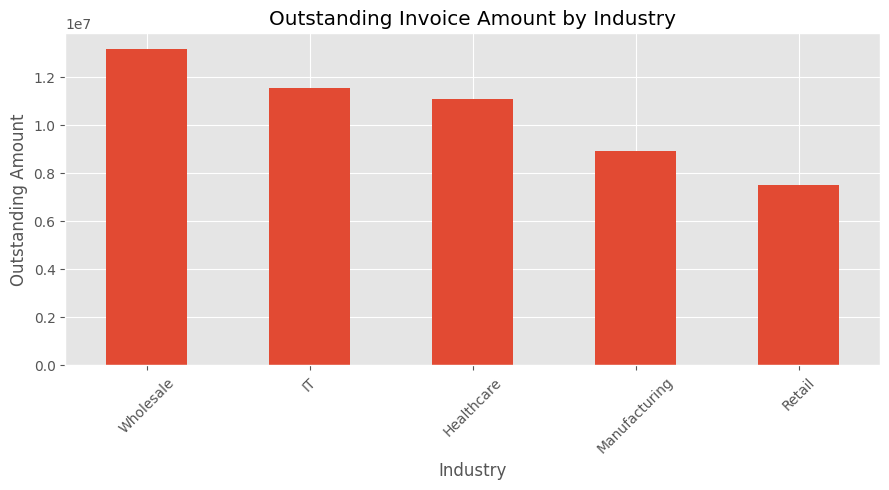

In [30]:
plt.figure(figsize=(9,5))

industry.plot(kind="bar")

plt.title("Outstanding Invoice Amount by Industry")

plt.ylabel("Outstanding Amount")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [35]:
credit["Utilization"] = (
    credit["Utilization"]
    .str.replace("%", "", regex=False)
    .astype(float)
)

In [36]:
ar = (
    invoices
    .merge(customers, on="Customer_ID", how="left")
    .merge(credit, on="Customer_ID", how="left", suffixes=("", "_Credit"))
)

ar.drop(columns=["Credit_Limit_Credit"], inplace=True)

In [37]:
credit["Utilization"].head(10)

0     56.46
1     63.99
2     91.99
3     14.61
4     85.06
5     60.09
6      5.15
7     47.09
8    107.00
9     72.40
Name: Utilization, dtype: float64

In [38]:
credit["Utilization"].dtype

dtype('float64')

# Analysis 8: Credit Utilization by Risk Rating

## Business Question

How does credit utilization vary across customer risk ratings?

Comparing utilization across risk groups helps identify customers with higher exposure and potential credit risk.

In [39]:
risk = (
    ar.dropna(subset=["Risk_Rating", "Utilization"])
      .groupby("Risk_Rating", as_index=False)["Utilization"]
      .mean()
      .sort_values("Utilization")
)

risk

,Risk_Rating,Utilization
0,High,60.462979
2,Medium,63.798735
1,Low,64.411305


<Figure size 600x500 with 0 Axes>

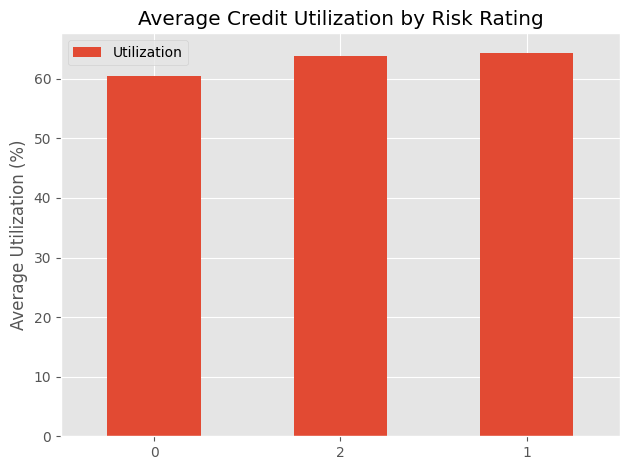

In [40]:
plt.figure(figsize=(6,5))

risk.plot(kind="bar")

plt.title("Average Credit Utilization by Risk Rating")

plt.ylabel("Average Utilization (%)")

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

# Analysis 9: High-Risk Customer Exposure

## Business Question

Which high-risk customers have the greatest credit exposure?

This analysis helps prioritize monitoring and collection efforts for customers with elevated financial risk.

In [41]:
high_risk = (
    ar[ar["Risk_Rating"] == "High"]
    .groupby("Customer_Name")["Current_Exposure"]
    .max()
    .sort_values(ascending=False)
    .head(10)
)

high_risk

Customer_Name
Customer 464    554676
Customer 255    524858
Customer 155    491294
Customer 353    448555
Customer 388    445196
Customer 483    441709
Customer 341    421612
Customer 201    414838
Customer 331    404435
Customer 254    395285
Name: Current_Exposure, dtype: int64

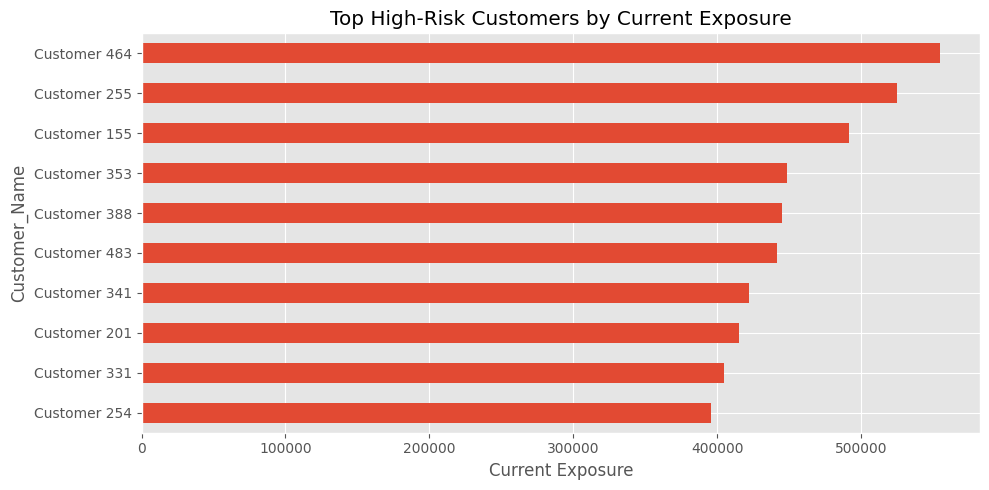

In [42]:
plt.figure(figsize=(10,5))

high_risk.sort_values().plot(kind="barh")

plt.title("Top High-Risk Customers by Current Exposure")

plt.xlabel("Current Exposure")

plt.tight_layout()

plt.show()

# Analysis 10: Sales vs Collections Trend

## Business Question

How do monthly sales compare with monthly cash collections?

Comparing sales and collections helps evaluate whether revenue growth is translating into actual cash inflows.

In [43]:
monthly_sales = (
    sales.groupby(sales["Sales_Date"].dt.to_period("M"))["Sales_Amount"]
    .sum()
)

monthly_collection = (
    payments.groupby(payments["Payment_Date"].dt.to_period("M"))["Amount_Paid"]
    .sum()
)

trend = pd.concat(
    [monthly_sales, monthly_collection],
    axis=1
).fillna(0)

trend.index = trend.index.astype(str)

trend

,Sales_Amount,Amount_Paid
2024-01,16784714.0,2852356
2024-02,16090648.0,3673702
2024-03,16277576.0,6338587
2024-04,18187212.0,6030406
2024-05,16127770.0,6845234
2024-06,15545168.0,7110653
2024-07,17232922.0,5569183
2024-08,18231033.0,6202283
2024-09,17424588.0,5378531
2024-10,18150130.0,6641203


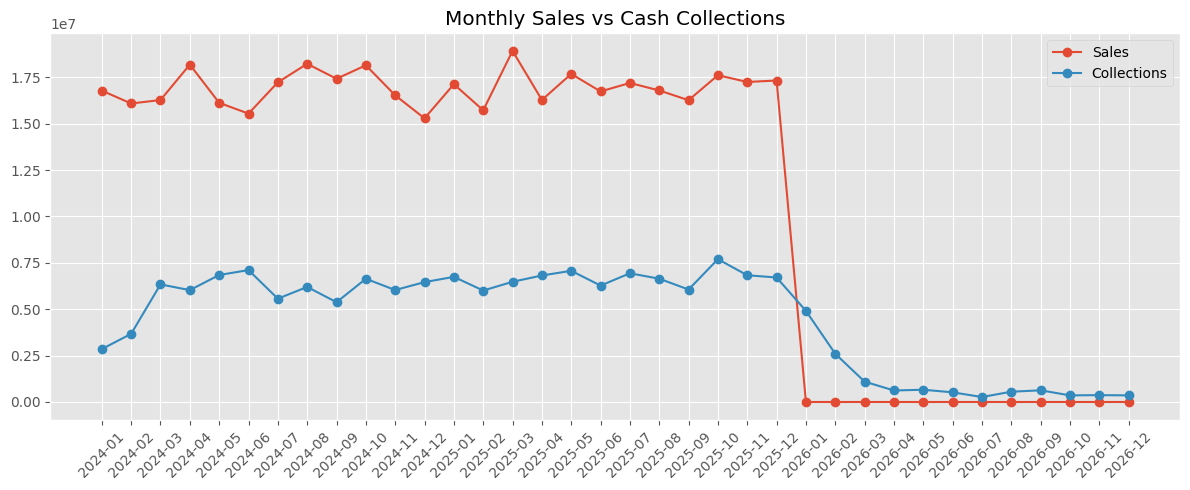

In [44]:
plt.figure(figsize=(12,5))

plt.plot(trend.index, trend["Sales_Amount"], marker="o", label="Sales")

plt.plot(trend.index, trend["Amount_Paid"], marker="o", label="Collections")

plt.legend()

plt.title("Monthly Sales vs Cash Collections")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# Analysis 11: Risk Rating Distribution

## Business Question

What is the distribution of customers across different credit risk categories?

Understanding the customer risk profile supports credit management and collection planning.

In [45]:
risk_dist = (
    credit["Risk_Rating"]
    .value_counts()
)

risk_dist

Risk_Rating
Medium    171
Low       167
High      162
Name: count, dtype: int64

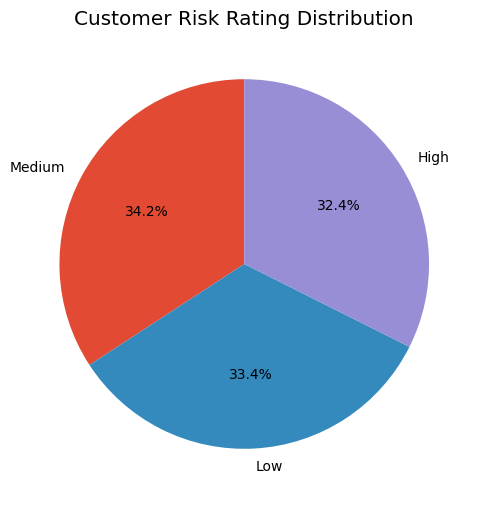

In [46]:
plt.figure(figsize=(6,6))

plt.pie(
    risk_dist,
    labels=risk_dist.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Risk Rating Distribution")

plt.show()

## Analysis 12: Executive KPI Summary

In [47]:
kpi = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Total Invoices",
        "Total Invoice Value",
        "Outstanding Invoice Value",
        "Total Payments",
        "Average Invoice Amount"
    ],
    "Value": [
        customers.shape[0],
        invoices.shape[0],
        invoices["Invoice_Amount"].sum(),
        ar[ar["Status"]!="Paid"]["Invoice_Amount"].sum(),
        payments["Amount_Paid"].sum(),
        invoices["Invoice_Amount"].mean()
    ]
})

kpi

,Metric,Value
0,Total Customers,5.000000e+02
1,Total Invoices,7.994000e+03
2,Total Invoice Value,2.023285e+08
3,Outstanding Invoice Value,5.224208e+07
4,Total Payments,1.623639e+08
5,Average Invoice Amount,2.531004e+04
